In [53]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.utils.data_loader import load_splits
from src.utils.config import WELFAKE_CONFIG

train_df, val_df, test_df = load_splits(WELFAKE_CONFIG)

Processed dataset for welfake already exists. Loading from disk.


In [54]:
# Dataset overview — size and null rates in the raw source
import pandas as pd
import os

raw_path = project_root / "data" / "raw" / "welfake" / "WELFake_Dataset.csv"
raw_df = pd.read_csv(raw_path)

print("=== Raw WELFake Dataset ===")
print(f"Total rows:        {len(raw_df):,}")
print(f"Label distribution: {raw_df['label'].value_counts().sort_index().to_dict()}  (0=real, 1=fake)")
print(f"  Real (0): {(raw_df['label']==0).sum():,}")
print(f"  Fake (1): {(raw_df['label']==1).sum():,}  ← Fake is majority in raw")
print()
print("Null counts (raw):")
print(raw_df[['title', 'text', 'label']].isnull().sum())
print()

# Show dedup effect per label
deduped = raw_df.drop_duplicates(subset=['text'])
print("=== Effect of deduplication on class balance ===")
for lbl, name in [(0, "Real"), (1, "Fake")]:
    before = (raw_df['label']==lbl).sum()
    after  = (deduped['label']==lbl).sum()
    print(f"  {name} (label={lbl}): {before:,} → {after:,}  ({before-after:,} duplicates removed, {(before-after)/before*100:.1f}%)")

print()
print("=== After Preprocessing ===")
total = len(train_df) + len(val_df) + len(test_df)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}  Total: {total:,}")
print(f"Dropped in preprocessing: {len(raw_df) - total:,} rows (nulls + exact duplicates)")
print()
print("Label encoding: 0 = Real, 1 = Fake")

=== Raw WELFake Dataset ===
Total rows:        72,134
Label distribution: {0: 35028, 1: 37106}  (0=real, 1=fake)
  Real (0): 35,028
  Fake (1): 37,106  ← Fake is majority in raw

Null counts (raw):
title    558
text      39
label      0
dtype: int64

=== Effect of deduplication on class balance ===
  Real (label=0): 35,028 → 34,620  (408 duplicates removed, 1.2%)
  Fake (label=1): 37,106 → 28,099  (9,007 duplicates removed, 24.3%)

=== After Preprocessing ===
Train: 50,915  Val: 6,364  Test: 6,365  Total: 63,644
Dropped in preprocessing: 8,490 rows (nulls + exact duplicates)

Label encoding: 0 = Real, 1 = Fake


/tmp/ipykernel_41280/2576591771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_41280/2576591771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_41280/2576591771.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


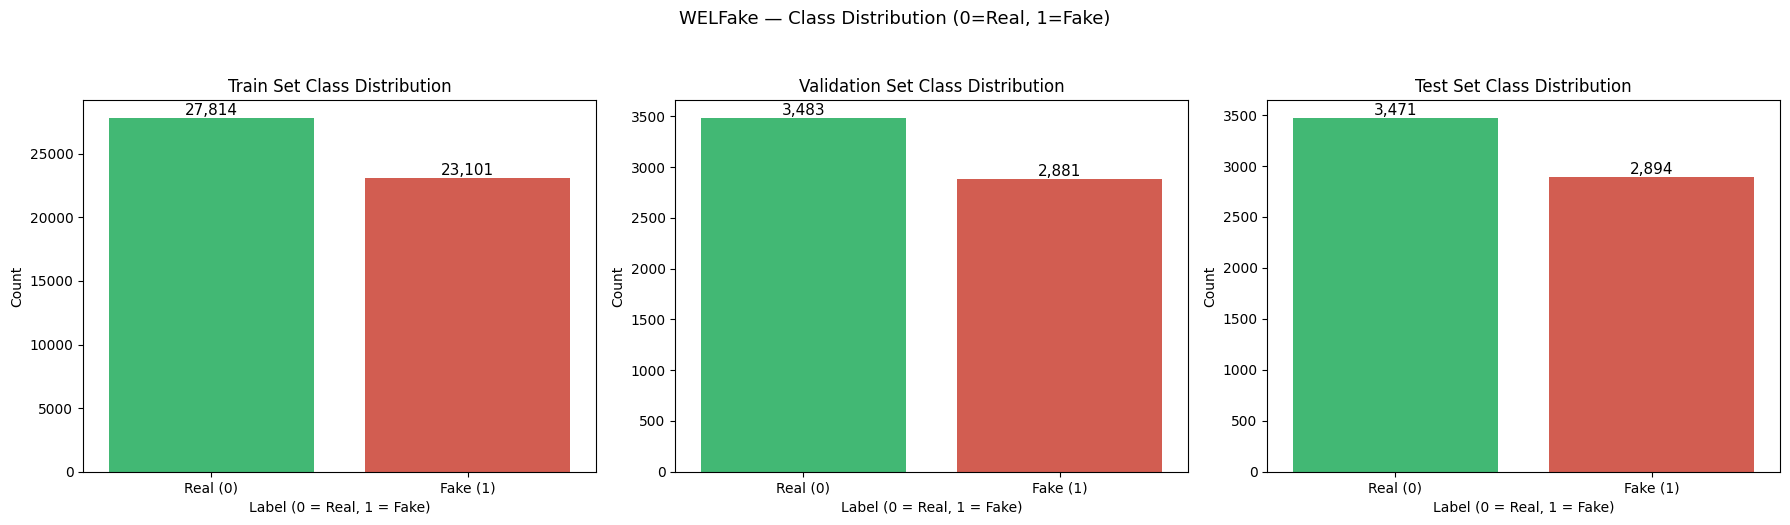

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(train_df, val_df, test_df, label_col):
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real (0)", 1: "Fake (1)"}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
        counts = df[label_col].value_counts().sort_index()
        sns.barplot(
            x=[label_names.get(l, str(l)) for l in counts.index],
            y=counts.values, ax=ax,
            palette=["#2ecc71", "#e74c3c"]  # green=Real, red=Fake
        )
        ax.set_title(f"{name} Set Class Distribution")
        ax.set_xlabel("Label (0 = Real, 1 = Fake)")
        ax.set_ylabel("Count")
        for p in ax.patches:
            ax.annotate(f"{int(p.get_height()):,}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=11)
    plt.suptitle("WELFake — Class Distribution (0=Real, 1=Fake)", fontsize=13, y=1.04)
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_df, val_df, test_df, WELFAKE_CONFIG.label_col)

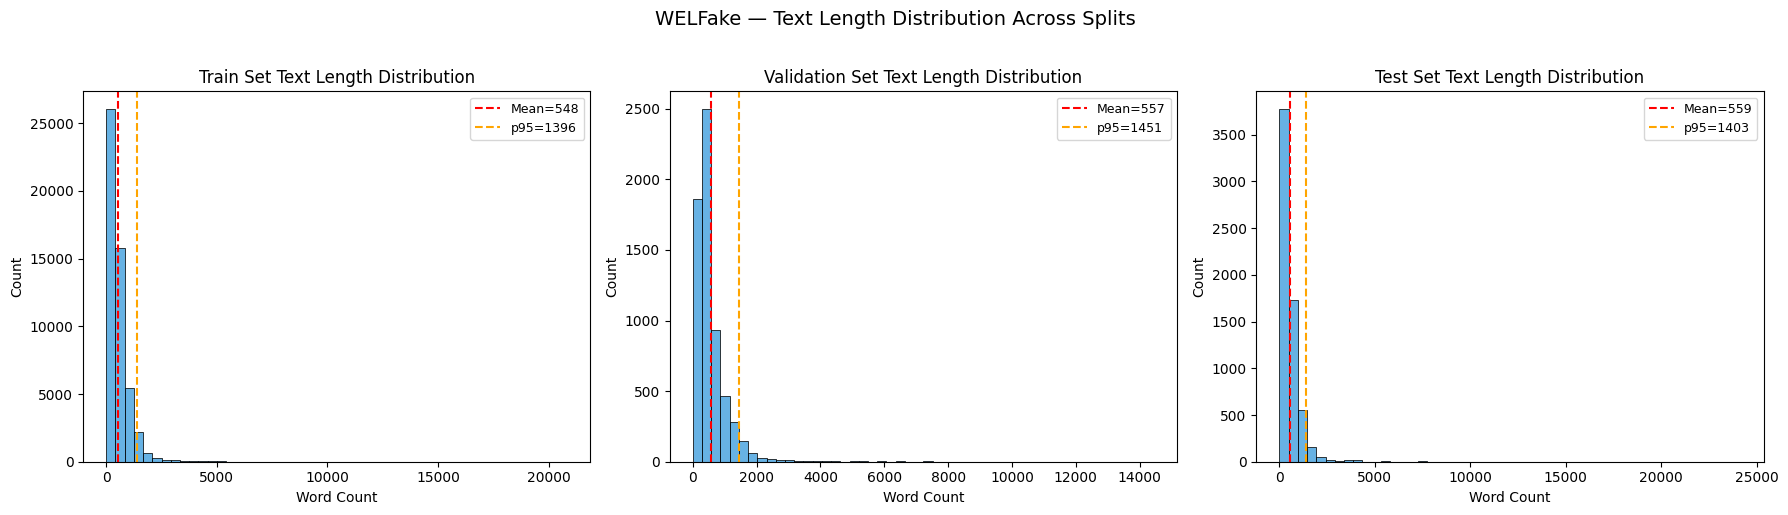

In [56]:
# Text length distribution (histogram) for all splits
def plot_text_length_distribution(train_df, val_df, test_df, text_col):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, df) in zip(axes, [("Train", train_df.copy()), ("Validation", val_df.copy()), ("Test", test_df.copy())]):
        df["text_length"] = df[text_col].apply(lambda x: len(str(x).split()))
        sns.histplot(df["text_length"], bins=50, ax=ax, color="#3498db")
        ax.axvline(df["text_length"].mean(), color="red", linestyle="--", label=f"Mean={df['text_length'].mean():.0f}")
        ax.axvline(df["text_length"].quantile(0.95), color="orange", linestyle="--", label=f"p95={df['text_length'].quantile(0.95):.0f}")
        ax.set_title(f"{name} Set Text Length Distribution")
        ax.set_xlabel("Word Count")
        ax.legend(fontsize=9)
    plt.suptitle("WELFake — Text Length Distribution Across Splits", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_text_length_distribution(train_df, val_df, test_df, WELFAKE_CONFIG.text_col)

/tmp/ipykernel_41280/1028046592.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="text_length", data=df,


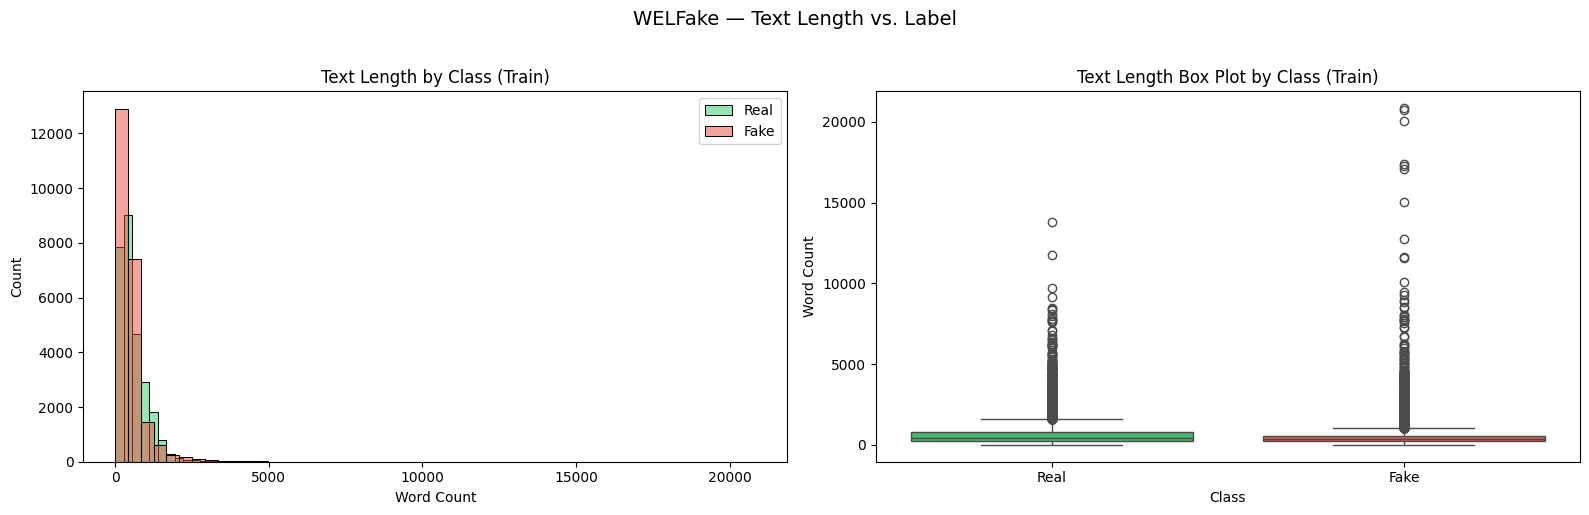

              count   mean    std  min    25%    50%    75%      max
label_name                                                          
Fake        23101.0  506.2  646.8  1.0  239.0  386.0  568.0  20839.0
Real        27814.0  583.6  550.9  4.0  249.0  435.0  790.8  13802.0


In [57]:
# Text length by class — are fake/real articles structurally different in length?
def plot_length_by_class(train_df, text_col, label_col):
    df = train_df.copy()
    df["text_length"] = df[text_col].apply(lambda x: len(str(x).split()))
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    df["label_name"] = df[label_col].map(label_names)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Overlapping histograms
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        subset = df[df[label_col] == label]["text_length"]
        sns.histplot(subset, bins=50, ax=axes[0], color=color,
                     alpha=0.5, label=label_names[label])
    axes[0].set_title("Text Length by Class (Train)")
    axes[0].set_xlabel("Word Count")
    axes[0].legend()

    # Box plot
    sns.boxplot(x="label_name", y="text_length", data=df,
                palette={"Real": "#2ecc71", "Fake": "#e74c3c"}, ax=axes[1])
    axes[1].set_title("Text Length Box Plot by Class (Train)")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Word Count")

    plt.suptitle("WELFake — Text Length vs. Label", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Print summary stats
    print(df.groupby("label_name")["text_length"].describe().round(1))

plot_length_by_class(train_df, WELFAKE_CONFIG.text_col, WELFAKE_CONFIG.label_col)

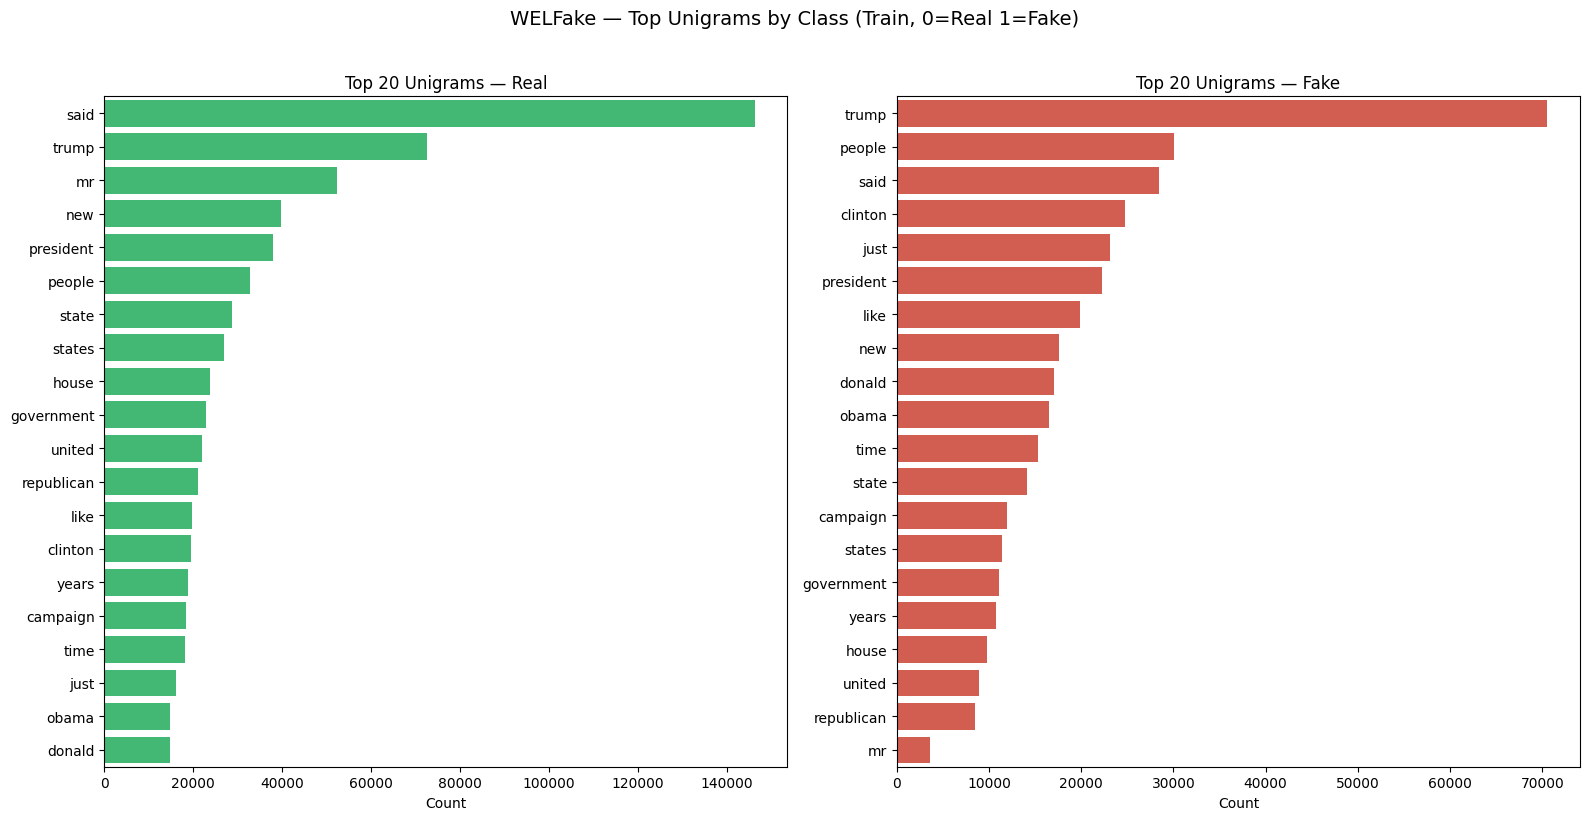

In [58]:
# Top 20 unigrams for each class in the training set
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_unigrams(train_df, text_col, label_col):
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    vectorizer = CountVectorizer(stop_words="english", max_features=20)
    X = vectorizer.fit_transform(train_df[text_col])
    feature_names = vectorizer.get_feature_names_out()

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    for ax, label in zip(axes, sorted(train_df[label_col].unique())):
        label_mask = (train_df[label_col] == label).values
        label_X = X[label_mask]
        counts = label_X.sum(axis=0).A1
        top_idx = counts.argsort()[-20:][::-1]
        sns.barplot(x=counts[top_idx], y=[feature_names[i] for i in top_idx], ax=ax,
                    color="#2ecc71" if label == 0 else "#e74c3c")
        ax.set_title(f"Top 20 Unigrams — {label_names[label]}")
        ax.set_xlabel("Count")
        ax.set_ylabel("")
    plt.suptitle("WELFake — Top Unigrams by Class (Train, 0=Real 1=Fake)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_top_unigrams(train_df, WELFAKE_CONFIG.text_col, WELFAKE_CONFIG.label_col)

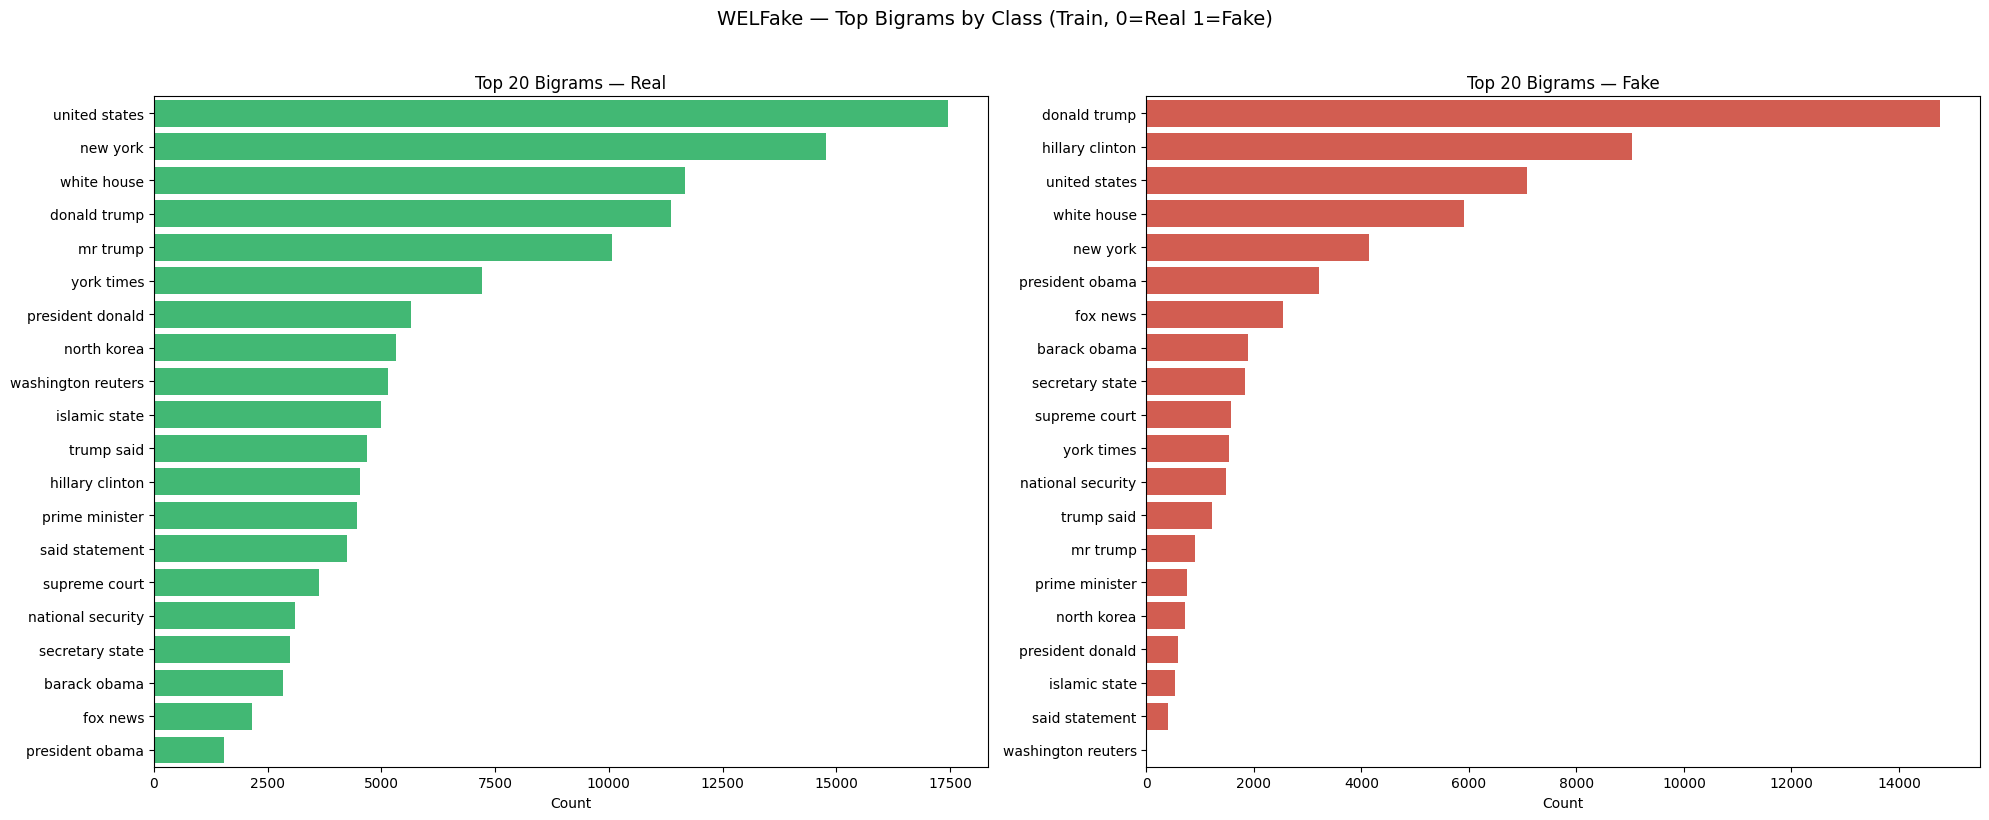

In [59]:
# Top 20 bigrams for each class in the training set
def plot_top_bigrams(train_df, text_col, label_col):
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2), max_features=20)
    X = vectorizer.fit_transform(train_df[text_col])
    feature_names = vectorizer.get_feature_names_out()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, label in zip(axes, sorted(train_df[label_col].unique())):
        label_mask = (train_df[label_col] == label).values
        label_X = X[label_mask]
        counts = label_X.sum(axis=0).A1
        top_idx = counts.argsort()[-20:][::-1]
        sns.barplot(x=counts[top_idx], y=[feature_names[i] for i in top_idx], ax=ax,
                    color="#2ecc71" if label == 0 else "#e74c3c")
        ax.set_title(f"Top 20 Bigrams — {label_names[label]}")
        ax.set_xlabel("Count")
        ax.set_ylabel("")
    plt.suptitle("WELFake — Top Bigrams by Class (Train, 0=Real 1=Fake)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_top_bigrams(train_df, WELFAKE_CONFIG.text_col, WELFAKE_CONFIG.label_col)

NameError: name 'WordCloud' is not defined

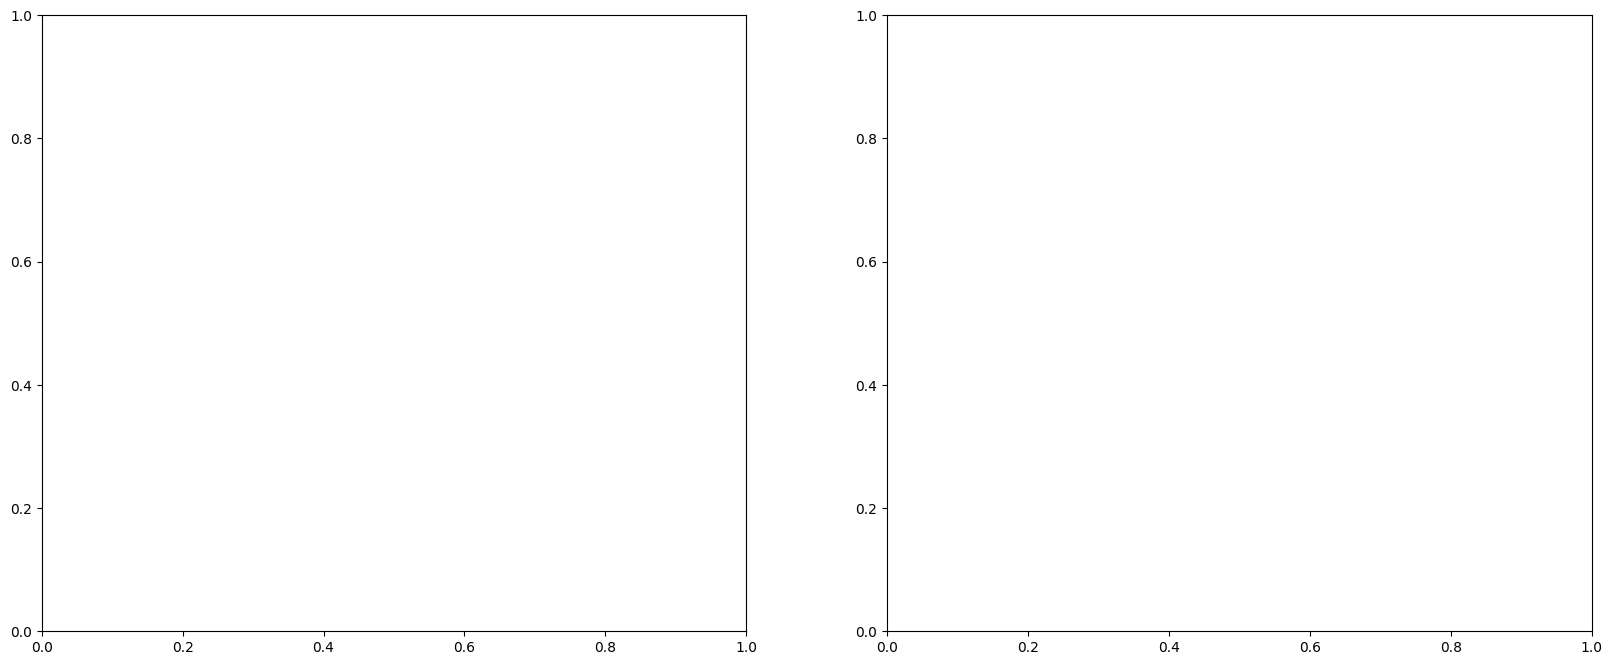

In [60]:
# Word cloud per class
def plot_wordclouds(train_df, text_col, label_col):
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, label in zip(axes, [0, 1]):
        text = " ".join(train_df[train_df[label_col] == label][text_col].dropna().astype(str))
        wc = WordCloud(width=800, height=400, background_color="white",
                        colormap="Greens" if label == 0 else "Reds",
                        max_words=150, stopwords=None).generate(text)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"{label_names[label]} News Word Cloud", fontsize=14)
    plt.suptitle("WELFake — Word Clouds by Class (Train, 0=Real 1=Fake)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_wordclouds(train_df, WELFAKE_CONFIG.text_col, WELFAKE_CONFIG.label_col)

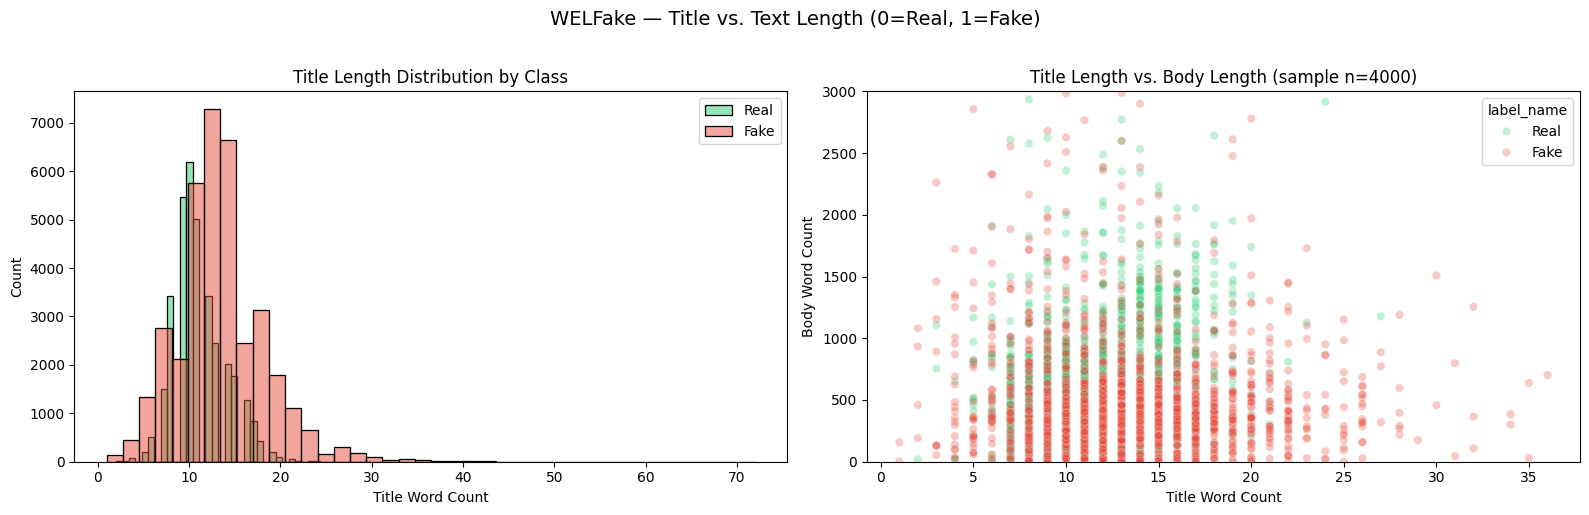

              count  mean  std  min   25%   50%   75%   max
label_name                                                 
Fake        36509.0  13.4  4.8  1.0  10.0  13.0  16.0  72.0
Real        35028.0  11.0  2.9  2.0   9.0  11.0  13.0  30.0


In [ ]:
# Title vs text length correlation — do articles with longer titles have longer bodies?
def plot_title_text_correlation(train_df):
    import pandas as pd
    # Load raw to get title column (processed df has combined text)
    raw_path = project_root / "data" / "raw" / "welfake" / "WELFake_Dataset.csv"
    raw = pd.read_csv(raw_path).dropna(subset=["title", "text"])
    raw["title_len"] = raw["title"].apply(lambda x: len(str(x).split()))
    raw["text_len"]  = raw["text"].apply(lambda x: len(str(x).split()))
    # WELFake raw: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    raw["label_name"] = raw["label"].map(label_names)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Title length distribution by class
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        sns.histplot(raw[raw["label"] == label]["title_len"], bins=40,
                     ax=axes[0], color=color, alpha=0.5, label=label_names[label])
    axes[0].set_title("Title Length Distribution by Class")
    axes[0].set_xlabel("Title Word Count")
    axes[0].legend()

    # Scatter: title len vs body len (sample 2000 per class for readability)
    sample = raw.groupby("label").apply(lambda g: g.sample(min(2000, len(g)), random_state=42)).reset_index(drop=True)
    sns.scatterplot(x="title_len", y="text_len", hue="label_name",
                    data=sample, ax=axes[1], alpha=0.3,
                    palette={"Real": "#2ecc71", "Fake": "#e74c3c"})
    axes[1].set_title("Title Length vs. Body Length (sample n=4000)")
    axes[1].set_xlabel("Title Word Count")
    axes[1].set_ylabel("Body Word Count")
    axes[1].set_ylim(0, 3000)

    plt.suptitle("WELFake — Title vs. Text Length", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(raw.groupby("label_name")["title_len"].describe().round(1))

plot_title_text_correlation(train_df)

In [ ]:
# Stats Summary table (mean/p95 length, vocab size, class balance)
def print_stats_summary(train_df, val_df, test_df, text_col, label_col):
    # WELFake: 0=Real, 1=Fake
    label_names = {0: "Real", 1: "Fake"}
    for split_name, df in zip(["Train", "Validation", "Test"], [train_df, val_df, test_df]):
        df = df.copy()
        df["text_length"] = df[text_col].apply(lambda x: len(str(x).split()))
        mean_length  = df["text_length"].mean()
        p95_length   = df["text_length"].quantile(0.95)
        vocab_size   = len(set(" ".join(df[text_col].dropna().astype(str)).split()))
        class_balance = df[label_col].value_counts(normalize=True).rename(label_names)

        print(f"{split_name} Set:")
        print(f"  Rows:                    {len(df):,}")
        print(f"  Mean Text Length:        {mean_length:.1f} words")
        print(f"  95th Percentile Length:  {p95_length:.0f} words")
        print(f"  Vocabulary Size:         {vocab_size:,}")
        print(f"  Class Balance:")
        for label, pct in class_balance.items():
            print(f"    {label}: {pct:.1%}")
        print()

print_stats_summary(train_df, val_df, test_df, WELFAKE_CONFIG.text_col, WELFAKE_CONFIG.label_col)

Train Set:
  Rows:                    50,915
  Mean Text Length:        548.5 words
  95th Percentile Length:  1396 words
  Vocabulary Size:         325,917
  Class Balance:
    Real: 54.6%
    Fake: 45.4%

Validation Set:
  Rows:                    6,364
  Mean Text Length:        557.5 words
  95th Percentile Length:  1451 words
  Vocabulary Size:         98,651
  Class Balance:
    Real: 54.7%
    Fake: 45.3%

Test Set:
  Rows:                    6,365
  Mean Text Length:        559.2 words
  95th Percentile Length:  1403 words
  Vocabulary Size:         97,631
  Class Balance:
    Real: 54.5%
    Fake: 45.5%

